## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Configuración de visualización
sns.set_style('darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

## 2. Carga de Datos

In [2]:
# Cargar el dataset
df = pd.read_csv('../resources/dataset/youtoxic_english_1000.csv')

print(f"✓ Dataset cargado exitosamente")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

✓ Dataset cargado exitosamente
Dimensiones: 1000 filas x 15 columnas


## 3. Exploración Inicial

In [29]:
# Primeras filas
df.head()

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,"If only people would just take a step back and not make this case about them, because it wasn't ...",False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to apprehend. They are trained to shoot to kill. And I...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' banners being held by white cunts is kinda patroniz...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do not like police officers. They are called Crimina...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should have not been shot 6 extra time. Shoot him once if ...",False,False,False,False,False,False,False,False,False,False,False,False


In [30]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CommentId        1000 non-null   object
 1   VideoId          1000 non-null   object
 2   Text             1000 non-null   object
 3   IsToxic          1000 non-null   bool  
 4   IsAbusive        1000 non-null   bool  
 5   IsThreat         1000 non-null   bool  
 6   IsProvocative    1000 non-null   bool  
 7   IsObscene        1000 non-null   bool  
 8   IsHatespeech     1000 non-null   bool  
 9   IsRacist         1000 non-null   bool  
 10  IsNationalist    1000 non-null   bool  
 11  IsSexist         1000 non-null   bool  
 12  IsHomophobic     1000 non-null   bool  
 13  IsReligiousHate  1000 non-null   bool  
 14  IsRadicalism     1000 non-null   bool  
dtypes: bool(12), object(3)
memory usage: 35.3+ KB


In [31]:
# Estadísticas descriptivas
df.describe()

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,13,997,2,2,2,2,2,2,2,2,2,1,2,1
top,Ugg2KwwX0V8-aXgCoAEC,9pr1oE34bIM,run them over,False,False,False,False,False,False,False,False,False,False,False,False
freq,1,274,3,538,647,979,839,900,862,875,992,999,1000,988,1000


In [32]:
# Columnas del dataset
print("Columnas del dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

Columnas del dataset:
1. CommentId
2. VideoId
3. Text
4. IsToxic
5. IsAbusive
6. IsThreat
7. IsProvocative
8. IsObscene
9. IsHatespeech
10. IsRacist
11. IsNationalist
12. IsSexist
13. IsHomophobic
14. IsReligiousHate
15. IsRadicalism


## 4. Análisis de Valores Faltantes

In [33]:
# Valores nulos
missing_data = pd.DataFrame({
    'Columna': df.columns,
    'Valores Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Valores Nulos', ascending=False)

print("\n=== VALORES FALTANTES ===")
print(missing_data[missing_data['Valores Nulos'] > 0])

if missing_data['Valores Nulos'].sum() == 0:
    print("\n✓ No hay valores faltantes en el dataset")


=== VALORES FALTANTES ===
Empty DataFrame
Columns: [Columna, Valores Nulos, Porcentaje (%)]
Index: []

✓ No hay valores faltantes en el dataset


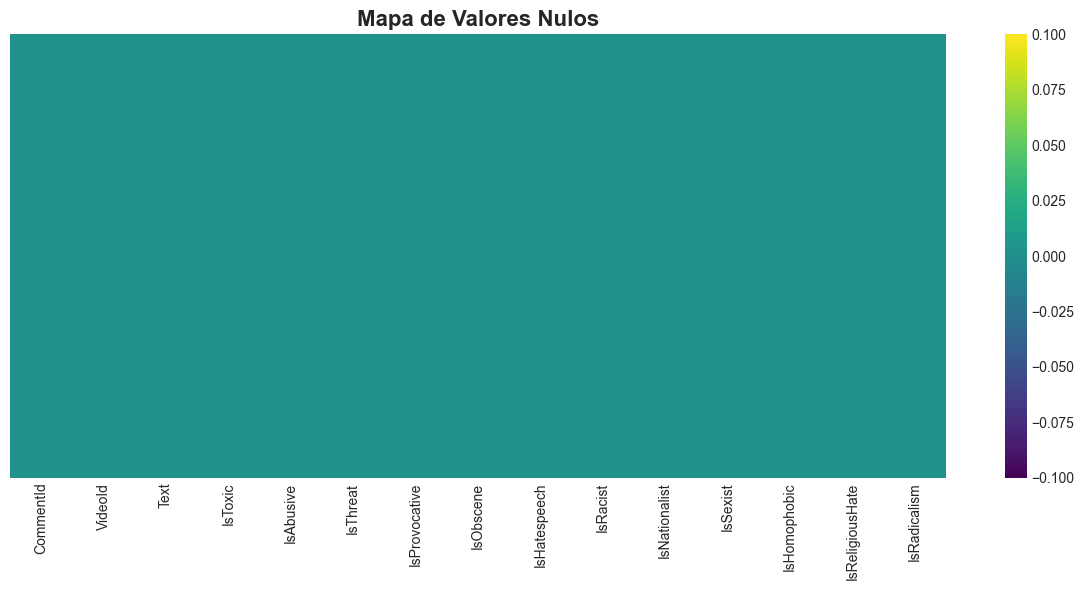

In [34]:
# Visualización de valores nulos
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Mapa de Valores Nulos', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Análisis de Duplicados

In [35]:
# Duplicados completos
duplicates_total = df.duplicated().sum()
print(f"Filas completamente duplicadas: {duplicates_total}")

# Duplicados en texto
duplicates_text = df.duplicated(subset=['Text']).sum()
print(f"Textos duplicados: {duplicates_text}")

# Duplicados en CommentId
duplicates_id = df.duplicated(subset=['CommentId']).sum()
print(f"CommentId duplicados: {duplicates_id}")

Filas completamente duplicadas: 0
Textos duplicados: 3
CommentId duplicados: 0


In [36]:
# Ver ejemplos de textos duplicados si existen
if duplicates_text > 0:
    print("\n=== EJEMPLOS DE TEXTOS DUPLICADOS ===")
    duplicate_texts = df[df.duplicated(subset=['Text'], keep=False)].sort_values('Text')
    print(f"Total de registros con texto duplicado: {len(duplicate_texts)}")
    print("\nPrimeros ejemplos:")
    display(duplicate_texts.head(10)[['Text', 'IsToxic', 'IsAbusive', 'IsHatespeech']])


=== EJEMPLOS DE TEXTOS DUPLICADOS ===
Total de registros con texto duplicado: 5

Primeros ejemplos:


,Text,IsToxic,IsAbusive,IsHatespeech
592,RUN THEM OVER,True,True,False
699,RUN THEM OVER,True,True,False
642,run them over,True,True,False
657,run them over,True,True,False
677,run them over,True,True,False


## 6. Análisis del Texto

In [5]:
# Longitud del texto
df['text_length'] = df['Text'].astype(str).apply(len)
df['word_count'] = df['Text'].astype(str).apply(lambda x: len(x.split()))

print("\n=== ESTADÍSTICAS DE TEXTO ===")
print(f"Longitud promedio: {df['text_length'].mean():.2f} caracteres")
print(f"Longitud mínima: {df['text_length'].min()} caracteres")
print(f"Longitud máxima: {df['text_length'].max()} caracteres")
print(f"\nPalabras promedio: {df['word_count'].mean():.2f}")
print(f"Palabras mínimas: {df['word_count'].min()}")
print(f"Palabras máximas: {df['word_count'].max()}")


=== ESTADÍSTICAS DE TEXTO ===
Longitud promedio: 185.55 caracteres
Longitud mínima: 3 caracteres
Longitud máxima: 4421 caracteres

Palabras promedio: 33.78
Palabras mínimas: 1
Palabras máximas: 815


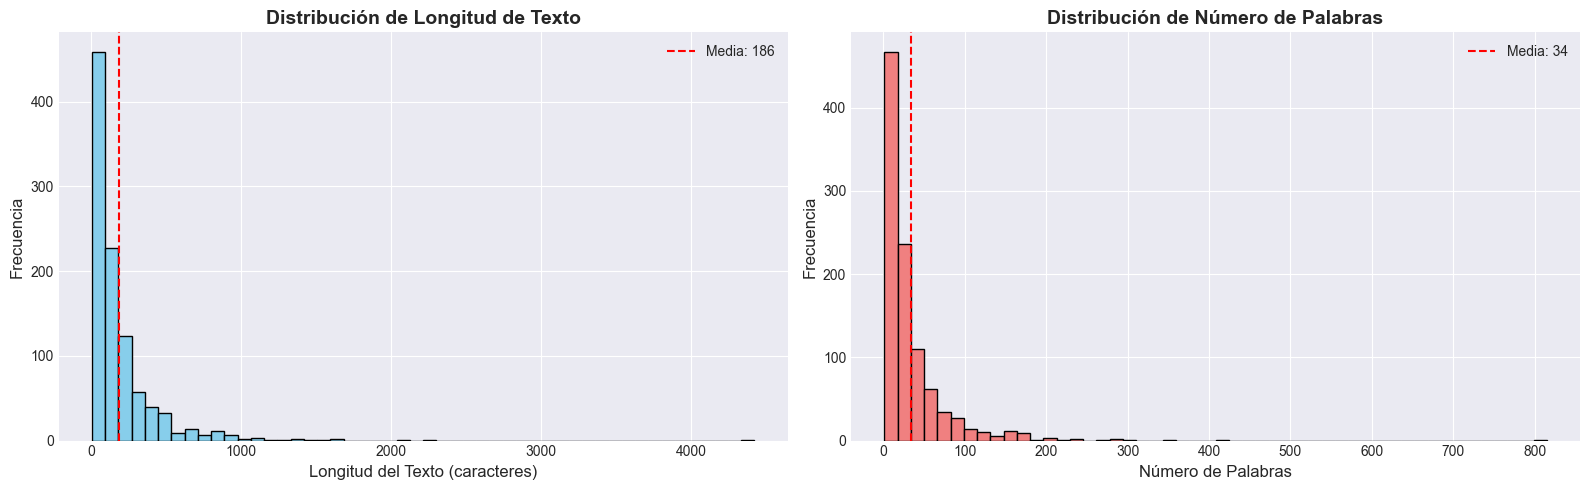

In [38]:
# Distribución de longitud de texto
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['text_length'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Longitud del Texto (caracteres)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Longitud de Texto', fontsize=14, fontweight='bold')
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--', label=f'Media: {df["text_length"].mean():.0f}')
axes[0].legend()

axes[1].hist(df['word_count'], bins=50, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Número de Palabras', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title('Distribución de Número de Palabras', fontsize=14, fontweight='bold')
axes[1].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Media: {df["word_count"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [39]:
# Textos vacíos o muy cortos
empty_texts = df[df['Text'].astype(str).str.strip() == ''].shape[0]
very_short_texts = df[df['word_count'] < 3].shape[0]

print(f"Textos vacíos: {empty_texts}")
print(f"Textos muy cortos (< 3 palabras): {very_short_texts}")

if very_short_texts > 0:
    print("\nEjemplos de textos muy cortos:")
    display(df[df['word_count'] < 3][['Text', 'word_count', 'IsToxic']].head(10))

Textos vacíos: 0
Textos muy cortos (< 3 palabras): 34

Ejemplos de textos muy cortos:


,Text,word_count,IsToxic
105,Wow!!!,1,False
118,CHRISTIANS ROCK!,2,False
131,So ratchet!lol\n,2,False
234,techno party!!!,2,False
243,Perfect police,2,False
244,Protesters suck,2,True
249,"Ah, beautiful.",2,True
303,on drugs*,2,False
342,Nicely done.,2,False
348,Great vid.,2,False


## 7. Análisis de Etiquetas de Toxicidad

In [3]:
# Columnas de etiquetas
label_columns = ['IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene', 
                 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 
                 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']

# Verificar valores únicos en cada columna de etiqueta
print("\n=== VALORES ÚNICOS EN ETIQUETAS ===")
for col in label_columns:
    if col in df.columns:
        print(f"{col}: {df[col].unique()}")


=== VALORES ÚNICOS EN ETIQUETAS ===
IsToxic: [False  True]
IsAbusive: [False  True]
IsThreat: [False  True]
IsProvocative: [False  True]
IsObscene: [False  True]
IsHatespeech: [False  True]
IsRacist: [False  True]
IsNationalist: [False  True]
IsSexist: [False  True]
IsHomophobic: [False]
IsReligiousHate: [False  True]
IsRadicalism: [False]


In [4]:
# Convertir valores booleanos a numéricos (si es necesario)
for col in label_columns:
    if col in df.columns:
        df[col] = df[col].map({'TRUE': 1, 'FALSE': 0, True: 1, False: 0}).fillna(df[col])

print("✓ Etiquetas convertidas a formato numérico")

✓ Etiquetas convertidas a formato numérico


In [59]:
# Conteo de cada tipo de toxicidad
toxicity_counts = {}
for col in label_columns:
    if col in df.columns:
        toxicity_counts[col] = df[col].sum()

toxicity_df = pd.DataFrame({
    'Tipo': list(toxicity_counts.keys()),
    'Cantidad': list(toxicity_counts.values()),
    'Porcentaje': [f"{(v/len(df)*100):.2f}%" for v in toxicity_counts.values()]
}).sort_values('Cantidad', ascending=False)

print("\n=== DISTRIBUCIÓN DE TIPOS DE TOXICIDAD ===")
display(toxicity_df)


=== DISTRIBUCIÓN DE TIPOS DE TOXICIDAD ===


,Tipo,Cantidad,Porcentaje
0,IsToxic,462,46.20%
1,IsAbusive,353,35.30%
3,IsProvocative,161,16.10%
5,IsHatespeech,138,13.80%
6,IsRacist,125,12.50%
4,IsObscene,100,10.00%
2,IsThreat,21,2.10%
10,IsReligiousHate,12,1.20%
7,IsNationalist,8,0.80%
8,IsSexist,1,0.10%


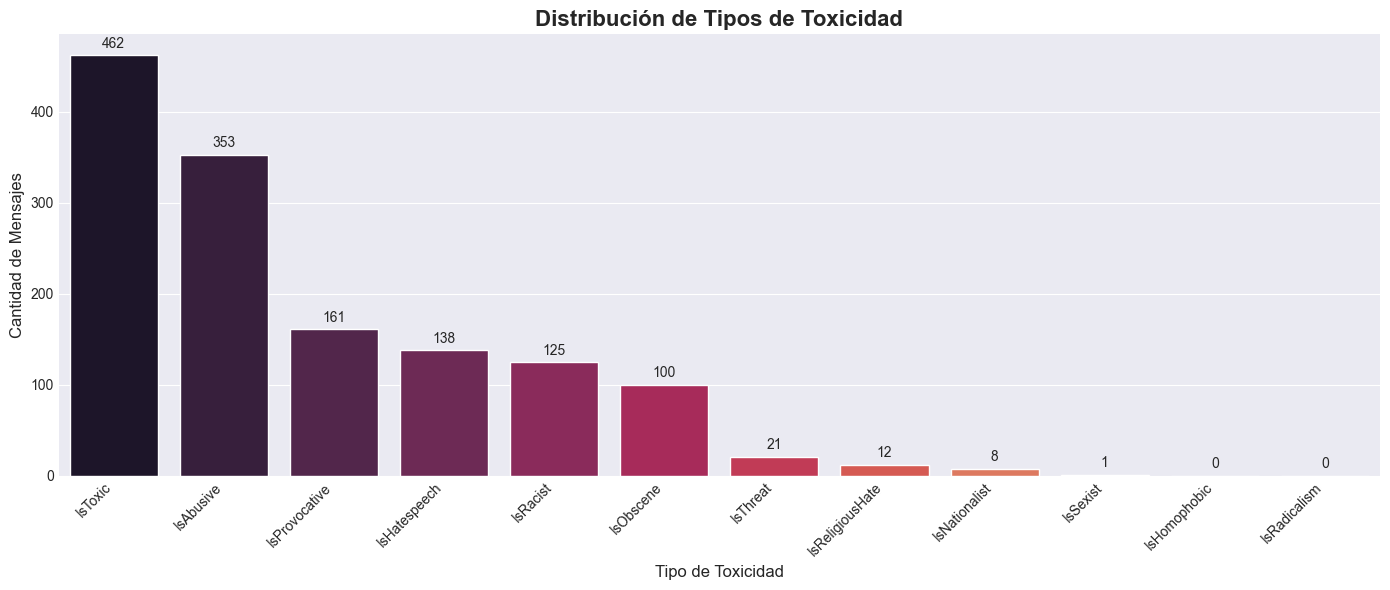

In [60]:
# Visualización de tipos de toxicidad
plt.figure(figsize=(14, 6))
sns.barplot(data=toxicity_df, x='Tipo', y='Cantidad', hue='Tipo', palette='rocket', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Tipos de Toxicidad', fontsize=16, fontweight='bold')
plt.ylabel('Cantidad de Mensajes', fontsize=12)
plt.xlabel('Tipo de Toxicidad', fontsize=12)

# Añadir valores en las barras
for i, v in enumerate(toxicity_df['Cantidad']):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [44]:
# Balance de clases (Tóxico vs No Tóxico)
toxic_count = df['IsToxic'].sum()
non_toxic_count = len(df) - toxic_count

print(f"\n=== BALANCE DE CLASES ===")
print(f"Mensajes Tóxicos: {toxic_count} ({toxic_count/len(df)*100:.2f}%)")
print(f"Mensajes No Tóxicos: {non_toxic_count} ({non_toxic_count/len(df)*100:.2f}%)")
print(f"\nRatio Tóxico/No Tóxico: 1:{non_toxic_count/toxic_count:.2f}")


=== BALANCE DE CLASES ===
Mensajes Tóxicos: 462 (46.20%)
Mensajes No Tóxicos: 538 (53.80%)

Ratio Tóxico/No Tóxico: 1:1.16


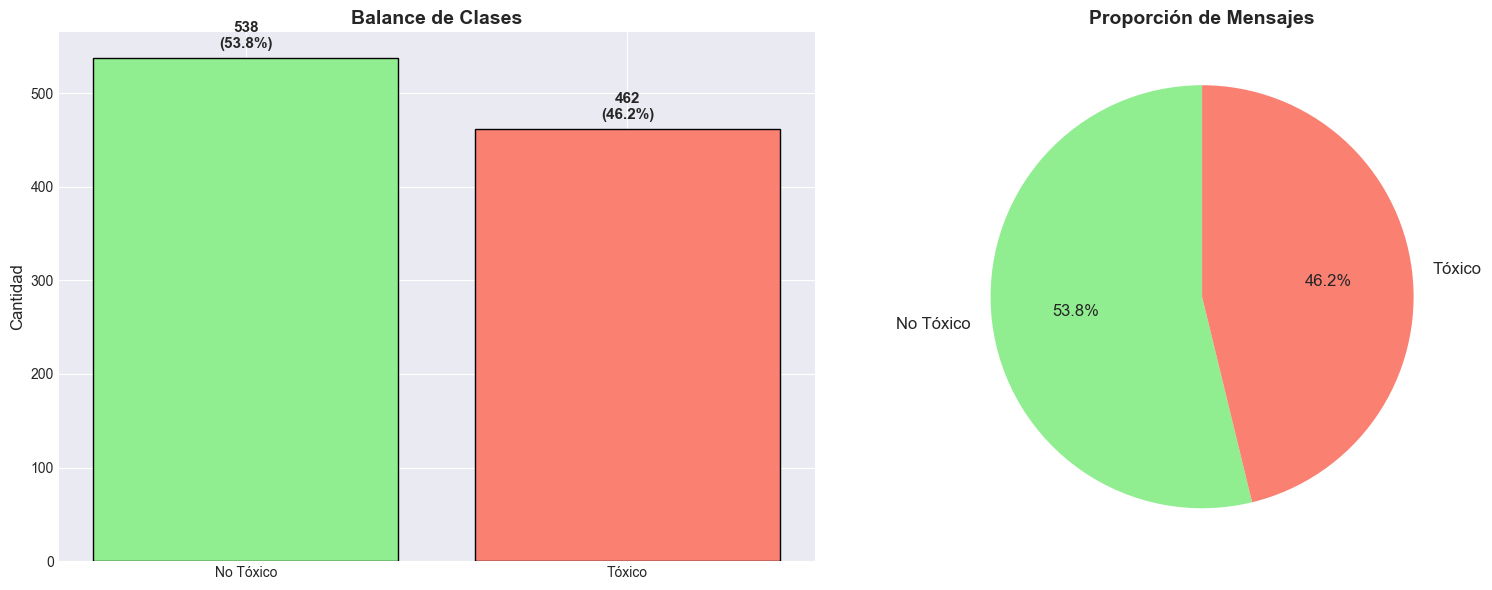

In [45]:
# Gráfico de balance de clases
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras
axes[0].bar(['No Tóxico', 'Tóxico'], [non_toxic_count, toxic_count], 
            color=['lightgreen', 'salmon'], edgecolor='black')
axes[0].set_ylabel('Cantidad', fontsize=12)
axes[0].set_title('Balance de Clases', fontsize=14, fontweight='bold')
axes[0].text(0, non_toxic_count + 10, f'{non_toxic_count}\n({non_toxic_count/len(df)*100:.1f}%)', 
             ha='center', fontsize=11, fontweight='bold')
axes[0].text(1, toxic_count + 10, f'{toxic_count}\n({toxic_count/len(df)*100:.1f}%)', 
             ha='center', fontsize=11, fontweight='bold')

# Gráfico de pastel
axes[1].pie([non_toxic_count, toxic_count], labels=['No Tóxico', 'Tóxico'], 
            autopct='%1.1f%%', colors=['lightgreen', 'salmon'], startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporción de Mensajes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Correlación entre Tipos de Toxicidad

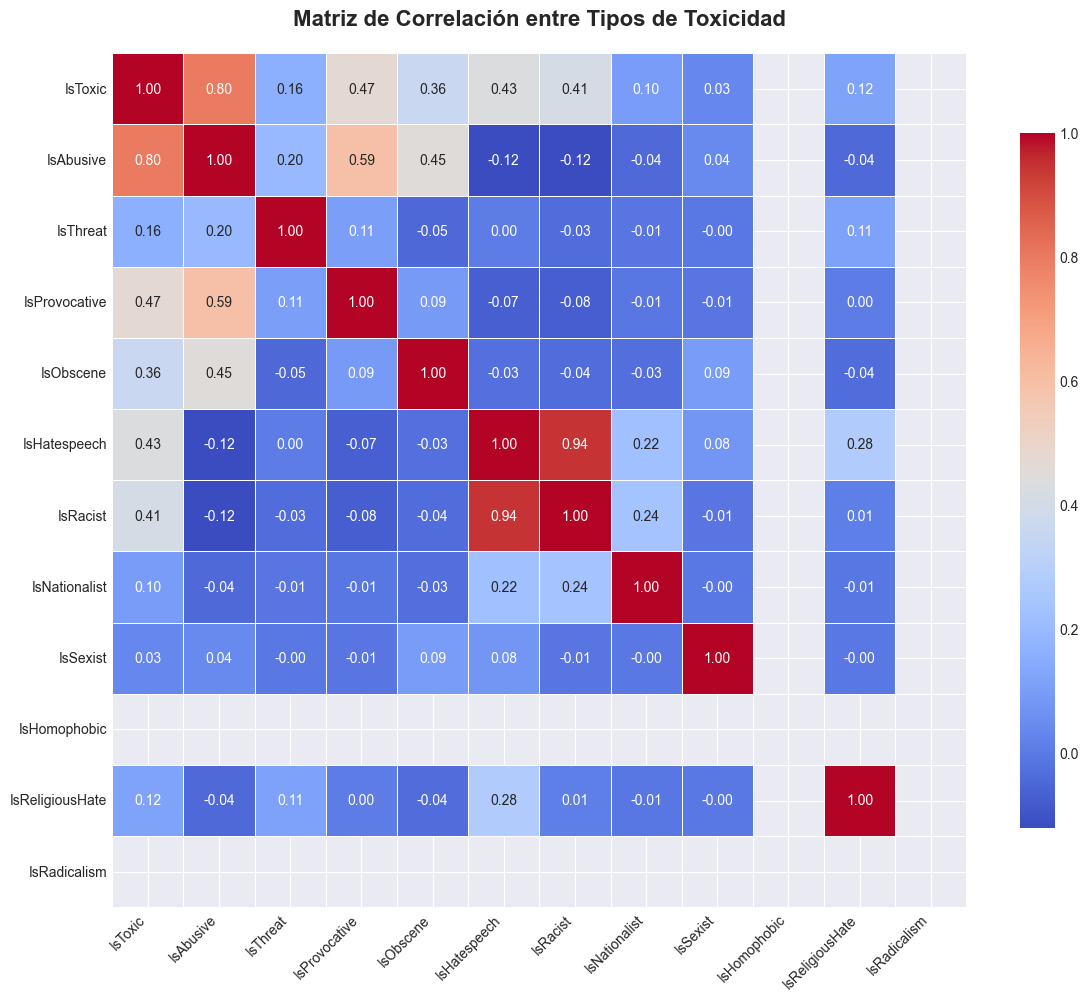

In [46]:
# Matriz de correlación
correlation_matrix = df[label_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación entre Tipos de Toxicidad', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [47]:
# Co-ocurrencia de etiquetas
print("\n=== CO-OCURRENCIA DE ETIQUETAS ===")
print("Mensajes con múltiples etiquetas de toxicidad:")

df['num_labels'] = df[label_columns].sum(axis=1)
multi_label_counts = df['num_labels'].value_counts().sort_index()

for num, count in multi_label_counts.items():
    print(f"  {int(num)} etiquetas: {count} mensajes ({count/len(df)*100:.2f}%)")


=== CO-OCURRENCIA DE ETIQUETAS ===
Mensajes con múltiples etiquetas de toxicidad:
  0 etiquetas: 538 mensajes (53.80%)
  2 etiquetas: 100 mensajes (10.00%)
  3 etiquetas: 294 mensajes (29.40%)
  4 etiquetas: 47 mensajes (4.70%)
  5 etiquetas: 15 mensajes (1.50%)
  6 etiquetas: 6 mensajes (0.60%)


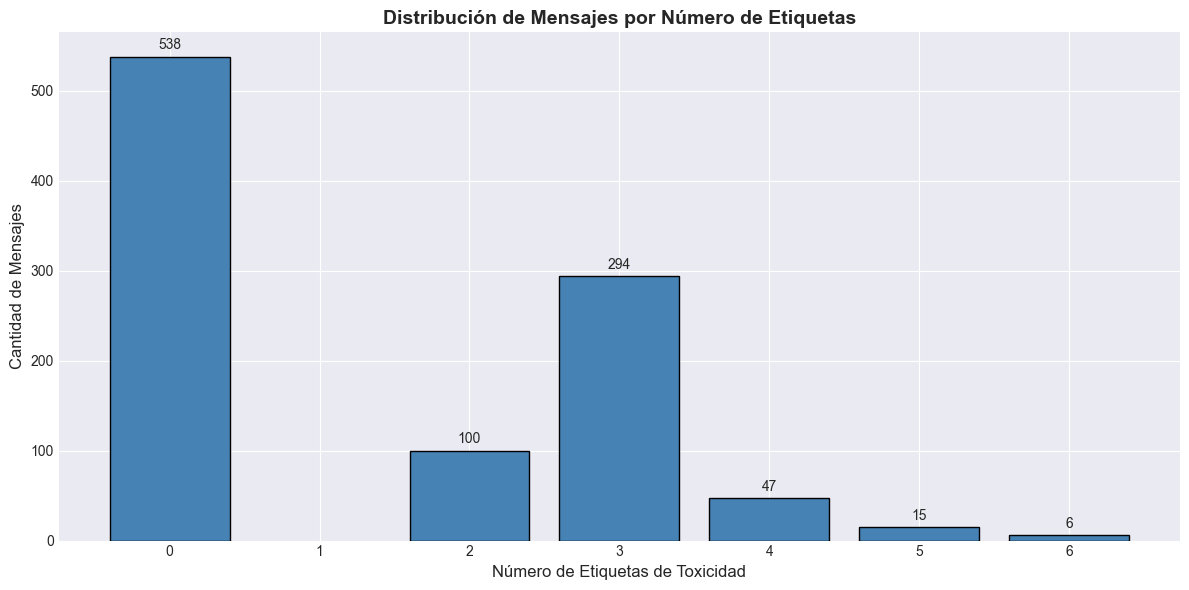

In [48]:
# Visualizar distribución de múltiples etiquetas
plt.figure(figsize=(12, 6))
plt.bar(multi_label_counts.index, multi_label_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('Número de Etiquetas de Toxicidad', fontsize=12)
plt.ylabel('Cantidad de Mensajes', fontsize=12)
plt.title('Distribución de Mensajes por Número de Etiquetas', fontsize=14, fontweight='bold')
plt.xticks(range(int(df['num_labels'].max()) + 1))

for i, v in enumerate(multi_label_counts.values):
    plt.text(multi_label_counts.index[i], v + 5, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 9. Análisis de Texto por Categoría

In [62]:
# Comparar longitud de texto entre mensajes tóxicos y no tóxicos
toxic_texts = df[df['IsToxic'] == 1]
non_toxic_texts = df[df['IsToxic'] == 0]

print("\n=== COMPARACIÓN DE LONGITUD DE TEXTO ===")
print(f"Mensajes Tóxicos:")
print(f"  - Longitud promedio: {toxic_texts['text_length'].mean():.2f} caracteres")
print(f"  - Palabras promedio: {toxic_texts['word_count'].mean():.2f}")
print(f"\nMensajes No Tóxicos:")
print(f"  - Longitud promedio: {non_toxic_texts['text_length'].mean():.2f} caracteres")
print(f"  - Palabras promedio: {non_toxic_texts['word_count'].mean():.2f}")


=== COMPARACIÓN DE LONGITUD DE TEXTO ===
Mensajes Tóxicos:
  - Longitud promedio: 189.39 caracteres
  - Palabras promedio: 34.60

Mensajes No Tóxicos:
  - Longitud promedio: 182.26 caracteres
  - Palabras promedio: 33.07


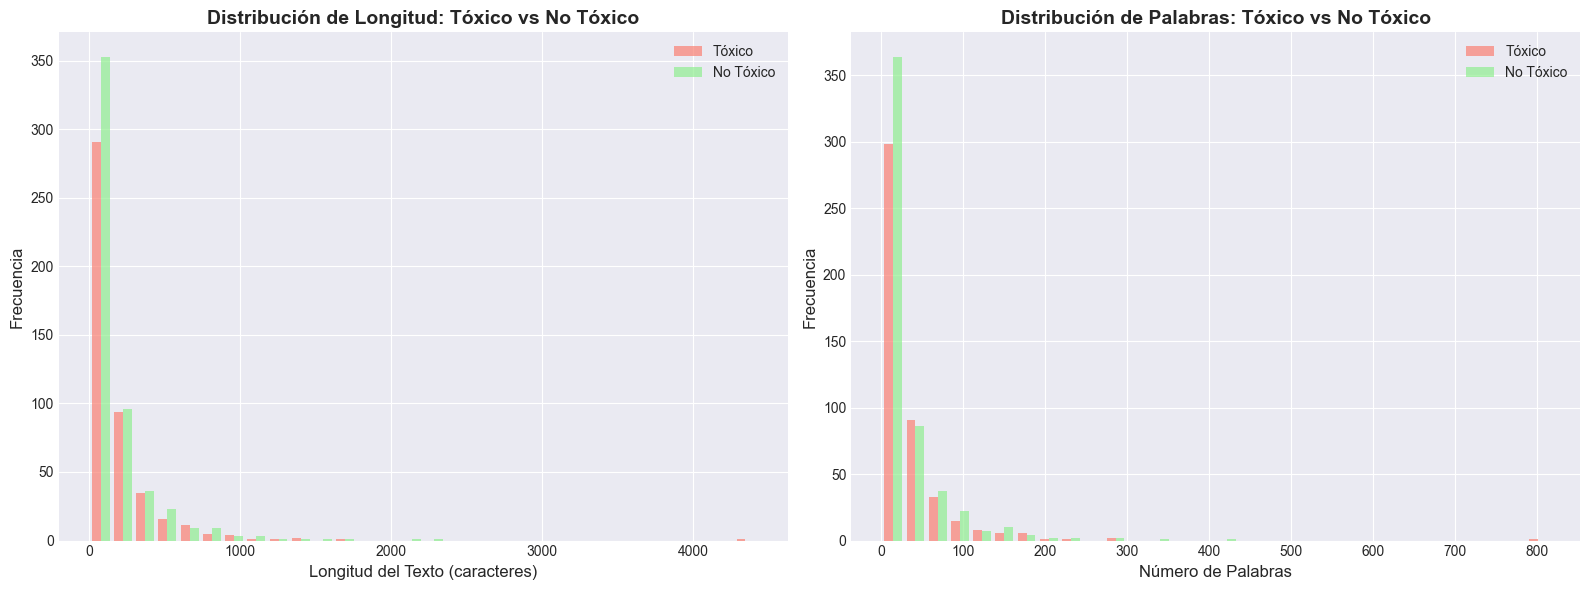

In [50]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Longitud de caracteres
axes[0].hist([toxic_texts['text_length'], non_toxic_texts['text_length']], 
             bins=30, label=['Tóxico', 'No Tóxico'], color=['salmon', 'lightgreen'], alpha=0.7)
axes[0].set_xlabel('Longitud del Texto (caracteres)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Longitud: Tóxico vs No Tóxico', fontsize=14, fontweight='bold')
axes[0].legend()

# Número de palabras
axes[1].hist([toxic_texts['word_count'], non_toxic_texts['word_count']], 
             bins=30, label=['Tóxico', 'No Tóxico'], color=['salmon', 'lightgreen'], alpha=0.7)
axes[1].set_xlabel('Número de Palabras', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title('Distribución de Palabras: Tóxico vs No Tóxico', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Análisis de Caracteres Especiales

In [63]:
# Detectar patrones en el texto
df['has_urls'] = df['Text'].astype(str).str.contains(r'http[s]?://|www\.', case=False, regex=True)
df['has_mentions'] = df['Text'].astype(str).str.contains(r'@\w+', regex=True)
df['has_hashtags'] = df['Text'].astype(str).str.contains(r'#\w+', regex=True)
df['has_emojis'] = df['Text'].astype(str).str.contains(r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF]', regex=True)
df['exclamation_count'] = df['Text'].astype(str).str.count('!')
df['question_count'] = df['Text'].astype(str).str.count('\\?')
df['uppercase_ratio'] = df['Text'].astype(str).apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)

print("\n=== ANÁLISIS DE CARACTERÍSTICAS DEL TEXTO ===")
print(f"Mensajes con URLs: {df['has_urls'].sum()} ({df['has_urls'].sum()/len(df)*100:.2f}%)")
print(f"Mensajes con menciones (@): {df['has_mentions'].sum()} ({df['has_mentions'].sum()/len(df)*100:.2f}%)")
print(f"Mensajes con hashtags (#): {df['has_hashtags'].sum()} ({df['has_hashtags'].sum()/len(df)*100:.2f}%)")
print(f"Mensajes con emojis: {df['has_emojis'].sum()} ({df['has_emojis'].sum()/len(df)*100:.2f}%)")
print(f"\nPromedio de signos de exclamación: {df['exclamation_count'].mean():.2f}")
print(f"Promedio de signos de interrogación: {df['question_count'].mean():.2f}")
print(f"Ratio promedio de mayúsculas: {df['uppercase_ratio'].mean():.2%}")


=== ANÁLISIS DE CARACTERÍSTICAS DEL TEXTO ===
Mensajes con URLs: 12 (1.20%)
Mensajes con menciones (@): 5 (0.50%)
Mensajes con hashtags (#): 9 (0.90%)
Mensajes con emojis: 6 (0.60%)

Promedio de signos de exclamación: 0.36
Promedio de signos de interrogación: 0.29
Ratio promedio de mayúsculas: 5.28%


In [64]:
# Comparar características entre mensajes tóxicos y no tóxicos
# Actualizar las variables después de añadir las nuevas columnas
toxic_texts = df[df['IsToxic'] == 1]
non_toxic_texts = df[df['IsToxic'] == 0]

comparison_features = ['exclamation_count', 'question_count', 'uppercase_ratio']

print("\n=== COMPARACIÓN DE CARACTERÍSTICAS: TÓXICO VS NO TÓXICO ===")
for feature in comparison_features:
    toxic_mean = toxic_texts[feature].mean()
    non_toxic_mean = non_toxic_texts[feature].mean()
    print(f"\n{feature}:")
    print(f"  - Tóxico: {toxic_mean:.4f}")
    print(f"  - No Tóxico: {non_toxic_mean:.4f}")
    print(f"  - Diferencia: {abs(toxic_mean - non_toxic_mean):.4f}")


=== COMPARACIÓN DE CARACTERÍSTICAS: TÓXICO VS NO TÓXICO ===

exclamation_count:
  - Tóxico: 0.4177
  - No Tóxico: 0.3104
  - Diferencia: 0.1073

question_count:
  - Tóxico: 0.2835
  - No Tóxico: 0.3011
  - Diferencia: 0.0176

uppercase_ratio:
  - Tóxico: 0.0561
  - No Tóxico: 0.0500
  - Diferencia: 0.0061


## 11. Limpieza del Dataset

### 10.1 Análisis Detallado de Textos Cortos

In [6]:
# Analizar textos cortos en detalle
short_texts = df[df['word_count'] < 3].copy()

print(f"=== ANÁLISIS DETALLADO DE TEXTOS CORTOS ===" )
print(f"Total de textos con menos de 3 palabras: {len(short_texts)}\n")

# Separar por categoría de toxicidad
short_toxic = short_texts[short_texts['IsToxic'] == 1]
short_non_toxic = short_texts[short_texts['IsToxic'] == 0]

print(f"Textos cortos TÓXICOS: {len(short_toxic)} ({len(short_toxic)/len(short_texts)*100:.1f}%)")
print(f"Textos cortos NO TÓXICOS: {len(short_non_toxic)} ({len(short_non_toxic)/len(short_texts)*100:.1f}%)")

# Mostrar todos los textos cortos organizados
print(f"\n{'='*80}")
print("TODOS LOS TEXTOS CORTOS:")
print(f"{'='*80}\n")

for idx, row in short_texts.iterrows():
    toxicity = "🔴 TÓXICO" if row['IsToxic'] == 1 else "🟢 NO TÓXICO"
    labels = [col.replace('Is', '') for col in label_columns if row.get(col, 0) == 1]
    label_str = f" [{', '.join(labels)}]" if labels else ""
    
    print(f"{idx}. {toxicity} | Palabras: {row['word_count']} | \"{row['Text']}\"{label_str}")

# Estadísticas adicionales
print(f"\n{'='*80}")
print("RESUMEN POR LONGITUD:")
print(f"{'='*80}")
word_count_dist = short_texts.groupby('word_count').agg({
    'Text': 'count',
    'IsToxic': 'sum'
}).rename(columns={'Text': 'Total', 'IsToxic': 'Tóxicos'})
word_count_dist['No Tóxicos'] = word_count_dist['Total'] - word_count_dist['Tóxicos']
word_count_dist['% Tóxicos'] = (word_count_dist['Tóxicos'] / word_count_dist['Total'] * 100).round(1)

print(word_count_dist)

=== ANÁLISIS DETALLADO DE TEXTOS CORTOS ===
Total de textos con menos de 3 palabras: 34

Textos cortos TÓXICOS: 12 (35.3%)
Textos cortos NO TÓXICOS: 22 (64.7%)

TODOS LOS TEXTOS CORTOS:

105. 🟢 NO TÓXICO | Palabras: 1 | "Wow!!!"
118. 🟢 NO TÓXICO | Palabras: 2 | "CHRISTIANS ROCK!"
131. 🟢 NO TÓXICO | Palabras: 2 | "So ratchet!lol
"
234. 🟢 NO TÓXICO | Palabras: 2 | "techno party!!!"
243. 🟢 NO TÓXICO | Palabras: 2 | "Perfect police"
244. 🔴 TÓXICO | Palabras: 2 | "Protesters suck" [Toxic, Abusive, Obscene]
249. 🔴 TÓXICO | Palabras: 2 | "Ah, beautiful." [Toxic, Abusive, Provocative]
303. 🟢 NO TÓXICO | Palabras: 2 | "on drugs*"
342. 🟢 NO TÓXICO | Palabras: 2 | "Nicely done."
348. 🟢 NO TÓXICO | Palabras: 2 | "Great vid."
353. 🟢 NO TÓXICO | Palabras: 2 | "@12:25 LMFAO"
433. 🟢 NO TÓXICO | Palabras: 1 | "wtf"
516. 🟢 NO TÓXICO | Palabras: 2 | "Thank you"
531. 🟢 NO TÓXICO | Palabras: 2 | "MERICA !!!"
545. 🟢 NO TÓXICO | Palabras: 2 | "Great interviews"
548. 🔴 TÓXICO | Palabras: 2 | "Vile cunt" [Toxi

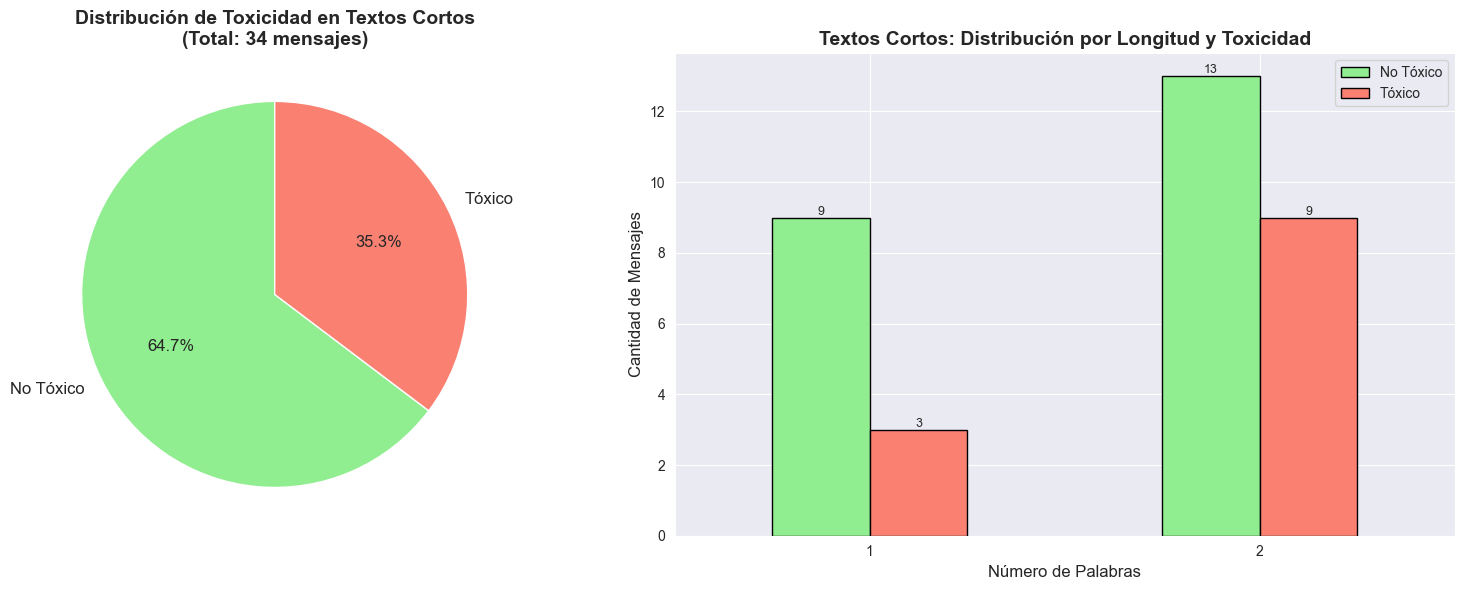


ANÁLISIS DE PATRONES:

📊 Mensajes cortos TÓXICOS más comunes:
   • "Protesters suck" → 1 veces
   • "Ah, beautiful." → 1 veces
   • "Vile cunt" → 1 veces
   • "Rich brats" → 1 veces
   • "Idiots" → 1 veces
   • "Idiotz" → 1 veces
   • "Stupid niggers" → 1 veces
   • "Stupid American" → 1 veces
   • "#blacklivesdontmatter" → 1 veces
   • "dumb mf" → 1 veces

📊 Mensajes cortos NO TÓXICOS más comunes:
   • "Wow!!!" → 1 veces
   • "CHRISTIANS ROCK!" → 1 veces
   • "So ratchet!lol
" → 1 veces
   • "techno party!!!" → 1 veces
   • "Perfect police" → 1 veces
   • "on drugs*" → 1 veces
   • "Nicely done." → 1 veces
   • "Great vid." → 1 veces
   • "@12:25 LMFAO" → 1 veces
   • "wtf" → 1 veces


In [7]:
# Visualización de textos cortos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Distribución de textos cortos por toxicidad
toxicity_short = short_texts['IsToxic'].value_counts()
colors_pie = ['lightgreen', 'salmon']
axes[0].pie([len(short_non_toxic), len(short_toxic)], 
            labels=['No Tóxico', 'Tóxico'],
            autopct='%1.1f%%', 
            colors=colors_pie,
            startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title(f'Distribución de Toxicidad en Textos Cortos\n(Total: {len(short_texts)} mensajes)', 
                  fontsize=14, fontweight='bold')

# Gráfico 2: Distribución por número de palabras
word_count_data = short_texts.groupby(['word_count', 'IsToxic']).size().unstack(fill_value=0)
word_count_data.plot(kind='bar', ax=axes[1], color=['lightgreen', 'salmon'], edgecolor='black')
axes[1].set_xlabel('Número de Palabras', fontsize=12)
axes[1].set_ylabel('Cantidad de Mensajes', fontsize=12)
axes[1].set_title('Textos Cortos: Distribución por Longitud y Toxicidad', fontsize=14, fontweight='bold')
axes[1].legend(['No Tóxico', 'Tóxico'], fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Añadir valores en las barras
for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=9)

plt.tight_layout()
plt.show()

# Análisis de patrones en textos cortos
print(f"\n{'='*80}")
print("ANÁLISIS DE PATRONES:")
print(f"{'='*80}")

# Palabras más comunes en textos cortos tóxicos
print("\n📊 Mensajes cortos TÓXICOS más comunes:")
toxic_short_counts = short_toxic['Text'].value_counts().head(10)
for text, count in toxic_short_counts.items():
    print(f"   • \"{text}\" → {count} veces")

# Palabras más comunes en textos cortos no tóxicos
print("\n📊 Mensajes cortos NO TÓXICOS más comunes:")
non_toxic_short_counts = short_non_toxic['Text'].value_counts().head(10)
for text, count in non_toxic_short_counts.items():
    print(f"   • \"{text}\" → {count} veces")

### 10.2 Decisión sobre Textos Cortos

Basándote en el análisis anterior, ahora puedes decidir qué textos cortos eliminar.

**Opciones disponibles:**
1. No eliminar ningún texto corto (mantener todos)
2. Eliminar solo textos de 1 palabra (12 mensajes)
3. Eliminar textos < 2 palabras (12 mensajes con 1 palabra)
4. Eliminar textos < 3 palabras (34 mensajes - opción original)
5. Eliminar solo textos cortos específicos (lista personalizada)

In [9]:
# Identificar textos neutrales/interjecciones sin valor analítico
print("=== IDENTIFICACIÓN DE TEXTOS NEUTRALES/INTERJECCIONES ===\n")

# Analizar textos cortos NO tóxicos que son neutrales
textos_neutrales_candidatos = short_non_toxic.copy()

print(f"📋 Todos los textos cortos NO TÓXICOS ({len(textos_neutrales_candidatos)} mensajes):\n")
for idx, row in textos_neutrales_candidatos.iterrows():
    print(f"   • \"{row['Text']}\" ({row['word_count']} palabra/s)")

# Lista sugerida de textos neutrales para eliminar
textos_neutrales_eliminar = [
    "Wow!!!",
    "wtf",
    "on drugs*",
    "techno party!!!",
    "@12:25 LMFAO",
    "So ratchet!lol\n"
]

print(f"\n\n💡 SUGERENCIA - Textos neutrales/interjecciones para eliminar:")
print("   (expresiones sin valor analítico para detección de odio)\n")
for texto in textos_neutrales_eliminar:
    if texto in textos_neutrales_candidatos['Text'].values:
        print(f"   ✓ \"{texto}\"")
    else:
        print(f"   ✗ \"{texto}\" (no encontrado)")

print(f"\n\n📊 Textos NO TÓXICOS que SÍ tienen valor (se mantendrán):")
textos_con_valor = textos_neutrales_candidatos[~textos_neutrales_candidatos['Text'].isin(textos_neutrales_eliminar)]
for idx, row in textos_con_valor.iterrows():
    print(f"   • \"{row['Text']}\" - tiene contenido relevante")

print(f"\n\n📌 RESUMEN:")
print(f"   Total textos cortos no tóxicos: {len(textos_neutrales_candidatos)}")
print(f"   Interjecciones/neutrales a eliminar: {len([t for t in textos_neutrales_eliminar if t in textos_neutrales_candidatos['Text'].values])}")
print(f"   Textos con valor a mantener: {len(textos_con_valor)}")

=== IDENTIFICACIÓN DE TEXTOS NEUTRALES/INTERJECCIONES ===

📋 Todos los textos cortos NO TÓXICOS (22 mensajes):

   • "Wow!!!" (1 palabra/s)
   • "CHRISTIANS ROCK!" (2 palabra/s)
   • "So ratchet!lol
" (2 palabra/s)
   • "techno party!!!" (2 palabra/s)
   • "Perfect police" (2 palabra/s)
   • "on drugs*" (2 palabra/s)
   • "Nicely done." (2 palabra/s)
   • "Great vid." (2 palabra/s)
   • "@12:25 LMFAO" (2 palabra/s)
   • "wtf" (1 palabra/s)
   • "Thank you" (2 palabra/s)
   • "MERICA !!!" (2 palabra/s)
   • "Great interviews" (2 palabra/s)
   • "#alllivesmatter" (1 palabra/s)
   • "Wow..........." (1 palabra/s)
   • "Respect!" (1 palabra/s)
   • "Awesome women." (2 palabra/s)
   • "Bravo!" (1 palabra/s)
   • "GOOD " (1 palabra/s)
   • "Darude...............sand...storm......." (1 palabra/s)
   • "ignorant" (1 palabra/s)
   • "Dats tuff" (2 palabra/s)


💡 SUGERENCIA - Textos neutrales/interjecciones para eliminar:
   (expresiones sin valor analítico para detección de odio)

   ✓ "Wow!!!"

In [8]:
# CONFIGURACIÓN: Elige qué textos cortos eliminar
# Cambia el valor de 'opcion_limpieza' según tu decisión

opcion_limpieza = 1  # Cambiar este número según lo que quieras hacer

print("=== OPCIONES DE LIMPIEZA PARA TEXTOS CORTOS ===\n")
print("1. No eliminar ningún texto corto (mantener todos)")
print("2. Eliminar solo textos de 1 palabra")
print("3. Eliminar textos con menos de 2 palabras")
print("4. Eliminar textos con menos de 3 palabras (opción original)")
print("5. Eliminar textos específicos (lista personalizada)")

print(f"\n✅ Opción seleccionada: {opcion_limpieza}")

# Textos específicos que podrías querer eliminar (opción 5)
textos_a_eliminar = [
    "Wow!!!",
    "wtf",
    "on drugs*"
]

# Visualizar qué se eliminará según la opción
if opcion_limpieza == 1:
    textos_eliminados = []
    print("\n➡️ NO se eliminarán textos cortos")
    
elif opcion_limpieza == 2:
    textos_eliminados = short_texts[short_texts['word_count'] == 1]
    print(f"\n➡️ Se eliminarán {len(textos_eliminados)} textos de 1 palabra:")
    for idx, row in textos_eliminados.iterrows():
        toxicity = "🔴" if row['IsToxic'] == 1 else "🟢"
        print(f"   {toxicity} \"{row['Text']}\"")
        
elif opcion_limpieza == 3:
    textos_eliminados = short_texts[short_texts['word_count'] < 2]
    print(f"\n➡️ Se eliminarán {len(textos_eliminados)} textos con < 2 palabras:")
    for idx, row in textos_eliminados.iterrows():
        toxicity = "🔴" if row['IsToxic'] == 1 else "🟢"
        print(f"   {toxicity} \"{row['Text']}\"")
        
elif opcion_limpieza == 4:
    textos_eliminados = short_texts[short_texts['word_count'] < 3]
    print(f"\n➡️ Se eliminarán {len(textos_eliminados)} textos con < 3 palabras (todos los cortos)")
    
elif opcion_limpieza == 5:
    textos_eliminados = short_texts[short_texts['Text'].isin(textos_a_eliminar)]
    print(f"\n➡️ Se eliminarán {len(textos_eliminados)} textos específicos:")
    for idx, row in textos_eliminados.iterrows():
        toxicity = "🔴" if row['IsToxic'] == 1 else "🟢"
        print(f"   {toxicity} \"{row['Text']}\"")
    print(f"\n💡 Edita la lista 'textos_a_eliminar' para personalizar")

print(f"\n📊 Resumen:")
print(f"   Total de textos cortos: {len(short_texts)}")
print(f"   Textos que se eliminarán: {len(textos_eliminados) if opcion_limpieza > 1 else 0}")
print(f"   Textos cortos que se mantendrán: {len(short_texts) - (len(textos_eliminados) if opcion_limpieza > 1 else 0)}")

=== OPCIONES DE LIMPIEZA PARA TEXTOS CORTOS ===

1. No eliminar ningún texto corto (mantener todos)
2. Eliminar solo textos de 1 palabra
3. Eliminar textos con menos de 2 palabras
4. Eliminar textos con menos de 3 palabras (opción original)
5. Eliminar textos específicos (lista personalizada)

✅ Opción seleccionada: 1

➡️ NO se eliminarán textos cortos

📊 Resumen:
   Total de textos cortos: 34
   Textos que se eliminarán: 0
   Textos cortos que se mantendrán: 34


In [10]:
# Crear una copia para limpieza
df_clean = df.copy()

print("=== PROCESO DE LIMPIEZA ===")
print(f"Tamaño inicial: {len(df_clean)} registros\n")

# 1. Eliminar duplicados basados en texto
initial_size = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['Text'], keep='first')
removed_duplicates = initial_size - len(df_clean)
print(f"✓ Duplicados eliminados: {removed_duplicates}")

# 2. Eliminar textos vacíos
initial_size = len(df_clean)
df_clean = df_clean[df_clean['Text'].astype(str).str.strip() != '']
removed_empty = initial_size - len(df_clean)
print(f"✓ Textos vacíos eliminados: {removed_empty}")

# 3. Eliminar textos neutrales/interjecciones sin valor analítico
textos_neutrales_eliminar = [
    "Wow!!!",
    "wtf",
    "on drugs*",
    "techno party!!!",
    "@12:25 LMFAO",
    "So ratchet!lol\n"
]

initial_size = len(df_clean)
df_clean = df_clean[~df_clean['Text'].isin(textos_neutrales_eliminar)]
removed_neutrals = initial_size - len(df_clean)
print(f"✓ Textos neutrales/interjecciones eliminados: {removed_neutrals}")

# 4. Resetear índice
df_clean = df_clean.reset_index(drop=True)

print(f"\n=== RESULTADO FINAL ===")
print(f"Tamaño final: {len(df_clean)} registros")
print(f"Registros eliminados: {len(df) - len(df_clean)} ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")

=== PROCESO DE LIMPIEZA ===
Tamaño inicial: 1000 registros

✓ Duplicados eliminados: 3
✓ Textos vacíos eliminados: 0
✓ Textos neutrales/interjecciones eliminados: 6

=== RESULTADO FINAL ===
Tamaño final: 991 registros
Registros eliminados: 9 (0.90%)


## 12. Verificación Post-Limpieza

In [11]:
# Verificar balance después de la limpieza
toxic_clean = df_clean['IsToxic'].sum()
non_toxic_clean = len(df_clean) - toxic_clean

print("\n=== BALANCE POST-LIMPIEZA ===")
print(f"Mensajes Tóxicos: {toxic_clean} ({toxic_clean/len(df_clean)*100:.2f}%)")
print(f"Mensajes No Tóxicos: {non_toxic_clean} ({non_toxic_clean/len(df_clean)*100:.2f}%)")
print(f"Ratio: 1:{non_toxic_clean/toxic_clean:.2f}")


=== BALANCE POST-LIMPIEZA ===
Mensajes Tóxicos: 459 (46.32%)
Mensajes No Tóxicos: 532 (53.68%)
Ratio: 1:1.16


In [67]:
# Distribución de etiquetas después de la limpieza
toxicity_counts_clean = {}
for col in label_columns:
    if col in df_clean.columns:
        toxicity_counts_clean[col] = df_clean[col].sum()

toxicity_df_clean = pd.DataFrame({
    'Tipo': list(toxicity_counts_clean.keys()),
    'Cantidad': list(toxicity_counts_clean.values()),
    'Porcentaje': [f"{(v/len(df_clean)*100):.2f}%" for v in toxicity_counts_clean.values()]
}).sort_values('Cantidad', ascending=False)

print("\n=== DISTRIBUCIÓN DE TIPOS DE TOXICIDAD (POST-LIMPIEZA) ===")
display(toxicity_df_clean)


=== DISTRIBUCIÓN DE TIPOS DE TOXICIDAD (POST-LIMPIEZA) ===


,Tipo,Cantidad,Porcentaje
0,IsToxic,447,46.42%
1,IsAbusive,341,35.41%
3,IsProvocative,156,16.20%
5,IsHatespeech,135,14.02%
6,IsRacist,122,12.67%
4,IsObscene,98,10.18%
2,IsThreat,21,2.18%
10,IsReligiousHate,12,1.25%
7,IsNationalist,7,0.73%
8,IsSexist,1,0.10%


## 13. Ejemplos de Mensajes

In [68]:
# Ejemplos de mensajes no tóxicos
print("\n=== EJEMPLOS DE MENSAJES NO TÓXICOS ===")
non_toxic_samples = df_clean[df_clean['IsToxic'] == 0].sample(min(5, len(df_clean[df_clean['IsToxic'] == 0])))
for i, row in non_toxic_samples.iterrows():
    print(f"\n{i+1}. {row['Text'][:200]}..." if len(row['Text']) > 200 else f"\n{i+1}. {row['Text']}")


=== EJEMPLOS DE MENSAJES NO TÓXICOS ===

432. Denny was brained also with a fire extinguisher.

867. What j=kind of bandana was that guy wearing? It was light up

211. Dont call peacefully protest.. When you burn down a car lol

82. Do any of these protestors work for a living??  where do they get the (time) to do all this....

646. Pepper spray them. For them to create a dangerous situation for motorists they should get put in jail. This isn’t s peaceful protest if they are infringing upon other citizens rights to move freely an...


In [69]:
# Ejemplos de mensajes tóxicos
print("\n=== EJEMPLOS DE MENSAJES TÓXICOS ===")
toxic_samples = df_clean[df_clean['IsToxic'] == 1].sample(min(5, len(df_clean[df_clean['IsToxic'] == 1])))
for i, row in toxic_samples.iterrows():
    labels = [col.replace('Is', '') for col in label_columns if row.get(col, 0) == 1]
    print(f"\n{i+1}. {row['Text'][:200]}..." if len(row['Text']) > 200 else f"\n{i+1}. {row['Text']}")
    print(f"   Etiquetas: {', '.join(labels)}")


=== EJEMPLOS DE MENSAJES TÓXICOS ===

244. Kill all protesters
   Etiquetas: Toxic, Abusive, Threat

392. Stop advertising swisher sweets lol , ur a racist point blank  .
   Etiquetas: Toxic, Abusive

505. White Supremacy at its best !
   Etiquetas: Toxic, Hatespeech, Racist

592. Get a job!
   Etiquetas: Toxic, Abusive, Provocative

676. It's hilarious seeing these morons get hit by cars
   Etiquetas: Toxic, Abusive, Provocative


## 14. Guardar Dataset Limpio

In [12]:
# Seleccionar columnas relevantes para el dataset limpio
columns_to_save = ['CommentId', 'VideoId', 'Text'] + label_columns
df_final = df_clean[columns_to_save].copy()

# Guardar el dataset limpio
output_path = '../resources/dataset/youtoxic_english_1000_clean.csv'
df_final.to_csv(output_path, index=False)

print(f"✓ Dataset limpio guardado en: {output_path}")
print(f"Dimensiones finales: {df_final.shape[0]} filas x {df_final.shape[1]} columnas")

✓ Dataset limpio guardado en: ../resources/dataset/youtoxic_english_1000_clean.csv
Dimensiones finales: 991 filas x 15 columnas


## 15. Resumen del EDA

In [13]:
print("="*80)
print("                    RESUMEN DEL ANÁLISIS EXPLORATORIO")
print("="*80)
print(f"\n📊 DATASET ORIGINAL:")
print(f"   - Total de registros: {len(df)}")
print(f"   - Mensajes tóxicos: {df['IsToxic'].sum()} ({df['IsToxic'].sum()/len(df)*100:.2f}%)")
print(f"   - Mensajes no tóxicos: {len(df) - df['IsToxic'].sum()} ({(len(df) - df['IsToxic'].sum())/len(df)*100:.2f}%)")

print(f"\n🧹 LIMPIEZA REALIZADA:")
print(f"   - Duplicados eliminados: {removed_duplicates}")
print(f"   - Textos vacíos eliminados: {removed_empty}")
print(f"   - Textos neutrales/interjecciones eliminados: {removed_neutrals}")
print(f"   - Total eliminado: {len(df) - len(df_clean)} ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")

print(f"\n✅ DATASET LIMPIO:")
print(f"   - Total de registros: {len(df_clean)}")
print(f"   - Mensajes tóxicos: {toxic_clean} ({toxic_clean/len(df_clean)*100:.2f}%)")
print(f"   - Mensajes no tóxicos: {non_toxic_clean} ({non_toxic_clean/len(df_clean)*100:.2f}%)")
print(f"   - Longitud promedio: {df_clean['text_length'].mean():.2f} caracteres")
print(f"   - Palabras promedio: {df_clean['word_count'].mean():.2f}")

print(f"\n📁 ARCHIVO GUARDADO:")
print(f"   - Ubicación: {output_path}")
print(f"   - Columnas: {len(df_final.columns)}")

print("\n" + "="*80)
print("✨ EDA completado exitosamente!")
print("="*80)

                    RESUMEN DEL ANÁLISIS EXPLORATORIO

📊 DATASET ORIGINAL:
   - Total de registros: 1000
   - Mensajes tóxicos: 462 (46.20%)
   - Mensajes no tóxicos: 538 (53.80%)

🧹 LIMPIEZA REALIZADA:
   - Duplicados eliminados: 3
   - Textos vacíos eliminados: 0
   - Textos neutrales/interjecciones eliminados: 6
   - Total eliminado: 9 (0.90%)

✅ DATASET LIMPIO:
   - Total de registros: 991
   - Mensajes tóxicos: 459 (46.32%)
   - Mensajes no tóxicos: 532 (53.68%)
   - Longitud promedio: 187.14 caracteres
   - Palabras promedio: 34.06

📁 ARCHIVO GUARDADO:
   - Ubicación: ../resources/dataset/youtoxic_english_1000_clean.csv
   - Columnas: 15

✨ EDA completado exitosamente!
